In [1]:
# Giovanni: use utils.read_gbq to pull the data, it caches the data
# it takes almost the same input as pandas.read_gbq 
# see the docstrings in utils.py if in doubt
from utils import read_gbq, rename_cols #,compute_effect_per_unit
import matplotlib.pyplot as plt
from tableone import TableOne
from collections import Counter
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import os
from tqdm import tqdm
from utils import treatment_effect
from scipy.stats import norm, zscore

warnings.filterwarnings("ignore")

In [2]:
# test different values here 
WINDOW_SIZE=12
OFFSET=6

In [3]:
PROCEDURES=Path("./procedures")
# PROJECT_ID=os.getenv('PROJECTID')
# PROJECT_ID="clinical-entity-extraction"
PROJECT_ID = "physio-414520" 

In [4]:
# # Transfusiuon Data
transfusion_df=read_gbq(PROCEDURES / "transfusion.sql",project_id=PROJECT_ID)
transfusion_df=transfusion_df.sort_values(by=['patientunitstayid','offset'])
transfusion_df.offset=transfusion_df.offset/60

# HGB Data
hgb_df=read_gbq(PROCEDURES / "hgb.sql",project_id=PROJECT_ID)
hgb_df=hgb_df.sort_values(by=['patientunitstayid','offset'])
hgb_df.offset=hgb_df.offset/60

# Apache Data
apache_df=read_gbq(PROCEDURES / "apache.sql",project_id=PROJECT_ID)
apache_df=apache_df.sort_values(by=['patientunitstayid'])

# Fluids Data
fluids_df=read_gbq(PROCEDURES / "fluid_balance.sql",project_id=PROJECT_ID)
fluids_df=fluids_df.sort_values(by=['patientunitstayid','transfusion_offset'])
fluids_df.transfusion_offset=fluids_df.transfusion_offset/60

# Demographic data 
demographics_df=read_gbq(PROCEDURES / "demographics.sql",project_id=PROJECT_ID)

# GI Bleeder
gb_df=read_gbq(PROCEDURES / "gb.sql",project_id=PROJECT_ID)
gb_df['gi_bleeder']=True

# Length of stay
lengthStay_df = (read_gbq(PROCEDURES / "lengthStay.sql", project_id=PROJECT_ID)
                 .sort_values(by=['patientunitstayid']))
time_columns = ['ICU_Stay', 'Time_prior_ICU', 'hospitalDischargeOffset']
lengthStay_df[time_columns] = lengthStay_df[time_columns] / 60
lengthStay_df['Total_time'] = lengthStay_df['hospitalDischargeOffset'] - lengthStay_df['Time_prior_ICU']

# # Vitals
vitals = (read_gbq(PROCEDURES / "vitals.sql", project_id=PROJECT_ID)
                 .sort_values(by=['patientunitstayid']))
vitals.intakeoutputoffset=vitals.intakeoutputoffset/60

sep_df=read_gbq(PROCEDURES / "sepsis.sql",project_id=PROJECT_ID)
sep_df=sep_df.sort_values(by=['patientunitstayid'])
# 23479 uniqque patients

Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|


In [5]:
import utils

# Apply for hematologic conditions
demographics_df["hematologic_type"] = demographics_df["admit_diagnosis"].apply(
    lambda x: utils.find_condition_type(x, category="hematologic")
)

# Apply for kidney conditions
demographics_df["kidney_type"] = demographics_df["admit_diagnosis"].apply(
    lambda x: utils.find_condition_type(x, category="kidney")
)

from utils import classify_condition_category

demographics_df["condition_category"] = demographics_df["admit_diagnosis"].apply(classify_condition_category)


In [6]:
# Giovanni : utils.treatment_effect computes the average (or any function you want) HGB in window size before transfusion (treatment) as baseline_hgb(g/dl)
# and after transfusion intitiation + a OFFSET for estimating the post treatment effect

data=[]
for ix,group in tqdm(transfusion_df.groupby('patientunitstayid')):
    data.append(treatment_effect(
        group,
        hgb_df[hgb_df.patientunitstayid.isin(group.patientunitstayid)],
        WINDOW_SIZE,
        OFFSET,
        'mean')
        )

def merge_info(original, to_merge, merge_by):
    filter_merge =  to_merge[to_merge[merge_by].isin(original[merge_by].unique())]
    merged = pd.merge(original, filter_merge, how='left')
    return merged

100%|██████████| 19694/19694 [03:22<00:00, 97.41it/s] 


In [7]:
df=pd.concat(data).groupby('patientunitstayid').first().reset_index() # for now we only keep the first transfusion


df=df.merge(demographics_df,on='patientunitstayid',validate='1:1')
# df.age=df.age.replace('> 89',91).astype(float)
df.age=df.age.replace('> 89', 91)
df.age=pd.to_numeric(df.age, errors='coerce')

print(df['patientunitstayid'].nunique())

df=df[df['age'] >= 18]
print('Age', df['patientunitstayid'].nunique())

# 20 patients lower than 18

df=df[~df['patientunitstayid'].isin(gb_df['patientunitstayid'].unique())]
print('GI',df['patientunitstayid'].nunique())
# GI bleeders: 469
# Also removed GI bleeders in demographics query

post=df[df['post_treatment'].isna()]
df=df[df['post_treatment'].notna()]
print('post', df['patientunitstayid'].nunique())


base=df[df['baseline'].isna()]
df=df[df['baseline'].notna()]
print('baseline', df['patientunitstayid'].nunique())

15289
Age 15269
GI 15158
post 12255
baseline 10578


In [ ]:
import numpy as np

more=[]
def compute_effect_per_unit(row):
    if pd.isna(row['treatment_effect']) or pd.isna(row['treatment_value']):
        return np.nan
    if row['treatment_value'] == 0:
        return np.nan 
    if row['treatment_effect'] == 0:
        return 0.0
    x=row['treatment_effect'] / (row['treatment_value'] / 330.0)
    if(abs(x)>15):
        more.append((row['treatment_effect'], row['treatment_value']))
    return x    

df['treatment_effect_per_unit'] = df.apply(compute_effect_per_unit, axis=1)

df.treatment_effect_per_unit.describe()

count    10277.000000
mean         2.762322
std         15.983848
min       -297.000000
25%          0.417722
50%          1.301667
75%          2.400000
max        863.500000
Name: treatment_effect_per_unit, dtype: float64

In [12]:
#Giovanni: nomenclature note
# df=pd.concat(data).groupby('patientunitstayid').first().reset_index() # for now we only keep the first transfusion

df['age_quartile']=pd.qcut(df.age,[.0,.25,.5,.75,1.],precision=1).astype(str)


# Add length of stay to df
df=merge_info(df, lengthStay_df, 'patientunitstayid')


# ---------------
# Add apache score
apache_concat=apache_df[['patientunitstayid', 'apache_score']]
apache_concat=apache_concat.drop_duplicates()
df=df.merge(apache_concat, on='patientunitstayid', how='left', validate='1:1')
# ---------------

temp=fluids_df.merge(df[['patientunitstayid','treatment_offset']],on='patientunitstayid')
temp['delta']=temp.transfusion_offset-temp.treatment_offset
temp=temp.groupby('patientunitstayid').apply(lambda data: data.sort_values(by='delta').iloc[-1,:],include_groups=True)
temp=temp.reset_index(drop=True).drop(['treatment_offset','delta','transfusion_offset'],axis=1)
df=df.merge(temp,on='patientunitstayid',how='left',validate='1:1')

df=df[df.treatment_effect.notna()] # removes patients with missing values on treatment effect
df=df[df.treatment_offset>=0] # remove patients who receives transfusion before ICU admission


print(df.shape)
df['z_score']=zscore(df['treatment_effect'])
norm_df=df[df['z_score'].abs()<=3]
df=norm_df

print(df.shape)
df['z_score_value']=zscore(df['treatment_value'])
norm_df=df[df['z_score_value'].abs()<=3]
df=norm_df
print(df.shape)

df['treatment_effect_per_unit'] = df.apply(compute_effect_per_unit, axis=1)
# df['treatment_effect_per_unit']=df['treatment_effect']/(df['treatment_value']/330.0)
# df['treatment_effect_per_unit'].describe()

df['HGB Increment (g/dL) Quartile']=pd.qcut(df.treatment_effect,[.0,.25,.5,.75,1.],precision=1).astype(str)
df['baseline_quartile']=pd.qcut(df.baseline,[.0,.25,.5,.75,1.],precision=1).astype(str)


# Vitals 
# NOTE: Please review-----
vp_temp=vitals.merge(df[['patientunitstayid', 'treatment_offset']],on='patientunitstayid')
# REMINDER: Need to change this; use something other than iloc[0:, 1:5] in case more features are added
vp_temp=vp_temp.groupby('patientunitstayid').apply(lambda data: data.iloc[0:, 1:5]
                                                   .mean(),include_groups=False)
vp_temp=vp_temp.reset_index()
df=df.merge(vp_temp,on='patientunitstayid',how='left',validate='1:1')

df['has_sepsis'] = df['patientunitstayid'].isin(sep_df['patientunitstayid']).astype(int)
df.has_sepsis.value_counts()

sepsis_df=df[df['has_sepsis']==1]
non_sepsis_df=df[df['has_sepsis']==0]

exclude=['_window_size','_offset','aggfunc']

categorical=['gender','age_quartile','ethnicity','icu_outcome','hosp_outcome', 
             'hematologic_type', 'kidney_type', 'condition_category'] # Removed GI as they were excluded above

continuous=['initial_weight','treatment_effect', 'treatment_effect_per_unit', 
            'treatment_value','treatment_offset','baseline','netTotal',
           'Total_time', 'apache_score','SaO2', 'heartrate', 'respiration', 'bp']

(9088, 32)
(8989, 33)
(8870, 34)


In [13]:
responders=df[df['treatment_effect_per_unit']>=1.0]
non_responders=df[df['treatment_effect_per_unit']<1.0]

print(responders.shape)
print(non_responders.shape)

(5302, 41)
(3515, 41)


Analysis for responders vs non-responders

In [21]:
# change this to create table one for sepsis patients and non-sepsis patients
t1=TableOne(df,
         columns=categorical+continuous,
         categorical=categorical,
         groupby='response',
         pval=True,
         )
t1=rename_cols(t1)
# non_sepsis_t1

In [22]:
t1

Grouped by response  \
                                                                              Missing   
n                                                                                       
gender, n (%)                          Female                                           
                                       Male                                             
age_quartile, n (%)                    (17.9, 55.0]                                     
                                       (55.0, 66.0]                                     
                                       (66.0, 76.0]                                     
                                       (76.0, 91.0]                                     
ethnicity, n (%)                                                                        
                                       African American                                 
                                       Asian                                            
                                       Caucasian                                        
                                       Hispanic                                         
                                       Native American                                  
                                       Other/Unknown                                    
icu_outcome, n (%)                     deceased                                         
                                       discharged                                       
hosp_outcome, n (%)                    deceased                                         
                                       discharged                                       
hematologic_type, n (%)                Coagulopathy                                     
                                       Hematologic (Other)                              
                                       Leukemia                                         
                                       None                                             
                                       Pancytopenia                                     
                                       Sickle Cell Disease                              
                                       Thrombocytopenia                                 
                                       Neutropenia                                      
kidney_type, n (%)                     Dialysis Access                                  
                                       Kidney Failure                                   
                                       Kidney Surgery                                   
                                       Kidney Transplant                                
                                       None                                             
                                       Renal Disorder                                   
                                       Renal Obstruction                                
condition_category, n (%)              Cardiac                                          
                                       Endocrine/Metabolic                              
                                       Gastrointestinal                                 
                                       Hematologic                                      
                                       Infectious                                       
                                       Musculoskeletal/Orthopedic                       
                                       Neurologic                                       
                                       Obstetric/Gynecologic                            
                                       Oncologic                                        
                                       Other                                            
                                       Renal                 

In [23]:
t1.to_latex('t1_16th.tex')

IGNORE CELLS BELOW FOR NOW

IGNORE CELLS BELOW FOR NOW

IGNORE CELLS BELOW FOR NOW

IGNORE CELLS BELOW FOR NOW

In [14]:
df['response'] = df['treatment_effect_per_unit'].apply(lambda x: 'responder' if x >= 1.0 else 'non_responder')

print(df['response'].value_counts(normalize=True))
print(df['response'].value_counts())

response
responder        0.597745
non_responder    0.402255
Name: proportion, dtype: float64
response
responder        5302
non_responder    3568
Name: count, dtype: int64


In [19]:
# EDA and Statistical Analysis for Sepsis Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Function to compare numerical features between sepsis and non-sepsis groups
def compare_groups(df, column):
    responders = df[df['response'] == 'responder'][column]
    non_responders = df[df['response'] == 'non_responder'][column]
    
    # Perform t-test
    t_stat, p_value = stats.ttest_ind(responders, non_responders, nan_policy='omit')
    
    # Calculate standard deviations
    responders_std = responders.std()
    non_responders_std = non_responders.std()
    
    # Create formatted DataFrame with results including std dev
    results = pd.DataFrame({
        'Responders Mean (SD)': [f"{responders.mean():.2f} (±{responders_std:.2f})"],
        'Non-Responders Mean (SD)': [f"{non_responders.mean():.2f} (±{non_responders_std:.2f})"],
        'Mean Difference': [f"{(responders.mean() - non_responders.mean()):.2f}"],
        'P-value': [f"{'<0.001' if p_value < 0.001 else f'{p_value:.3f}'}"]
    })
    
    return results

# List of numerical features to analyze with readable labels
numerical_features = {
    'age': 'Age (years)',
    'initial_weight': 'Initial Weight (kg)', 
    'ICU_Stay': 'ICU Length of Stay (hours)',
    'Time_prior_ICU': 'Time Prior to ICU (hours)',
    'Total_time': 'Total Time (hours)',
    'netTotal': 'Net Fluid Balance (mL)',
    'intakeTotal': 'Total Fluid Intake (mL)',
    'outputTotal': 'Total Fluid Output (mL)',
    'treatment_effect': 'Treatment Effect',
    'baseline': 'Baseline Value'
}

# Create comparison table with improved formatting
comparison_results = pd.concat(
    [compare_groups(df, col) for col in numerical_features.keys()],
    keys=numerical_features.values()
)

# Display formatted table
print("\nComparison of Clinical Parameters Between Responders and Non-Responders")
print("=" * 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)
print(comparison_results.to_string(justify='left'))
print("=" * 100)
print("\nNote: P-values <0.001 are displayed as '<0.001'")



Comparison of Clinical Parameters Between Responders and Non-Responders
                             Responders Mean (SD) Non-Responders Mean (SD) Mean Difference P-value
Age (years)                0    64.59 (±16.02)         63.84 (±15.94)          0.75          0.030
Initial Weight (kg)        0    79.28 (±24.63)         87.13 (±27.18)         -7.86         <0.001
ICU Length of Stay (hours) 0  166.99 (±215.83)       169.33 (±194.87)         -2.34          0.602
Time Prior to ICU (hours)  0  -74.14 (±297.43)       -65.81 (±166.39)         -8.33          0.129
Total Time (hours)         0  409.27 (±555.10)       404.30 (±420.24)          4.97          0.649
Net Fluid Balance (mL)     0  457.71 (±956.81)      560.91 (±1264.41)       -103.20         <0.001
Total Fluid Intake (mL)    0  909.85 (±919.84)     1219.74 (±1523.60)       -309.90         <0.001
Total Fluid Output (mL)    0  471.31 (±689.54)      666.37 (±1019.40)       -195.05         <0.001
Treatment Effect           0      2.

<Figure size 1500x1000 with 0 Axes>

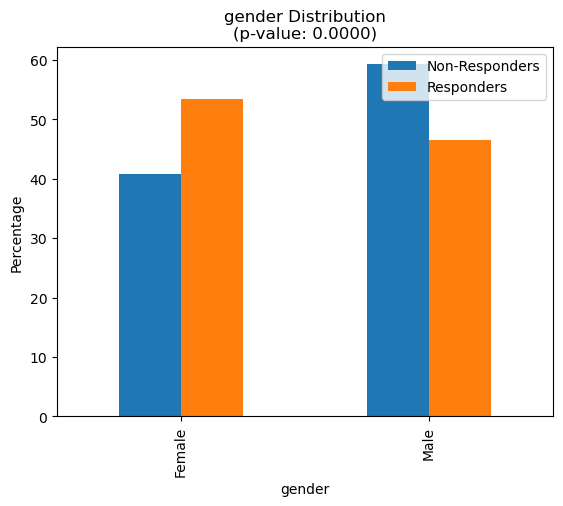

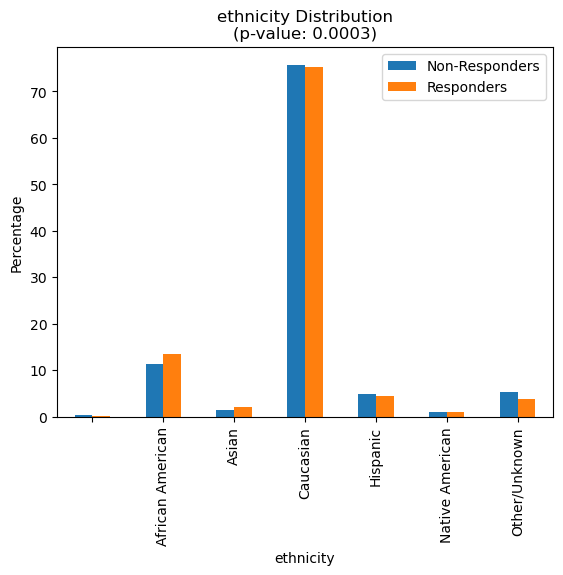

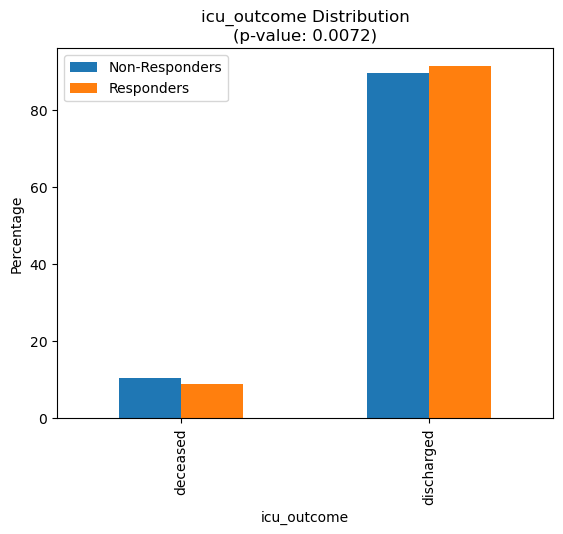

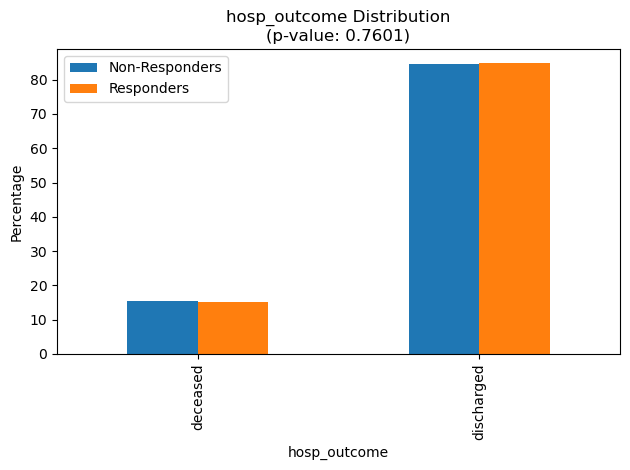

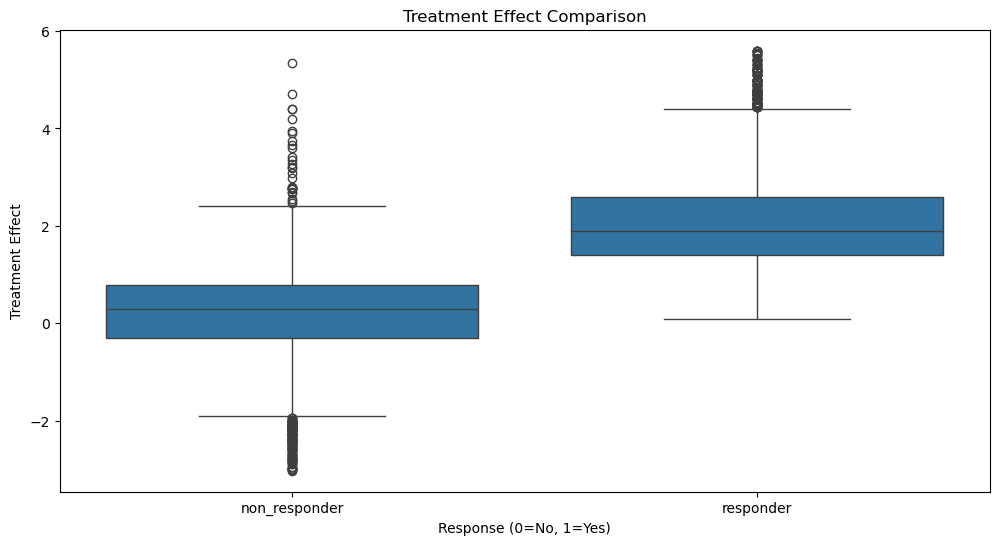


Outcome Analysis (percentages):
response                  non_responder  responder
icu_outcome hosp_outcome                          
deceased    deceased          10.054348   8.495008
            discharged         0.353261   0.207195
discharged  deceased           5.461957   6.762102
            discharged        84.130435  84.535694


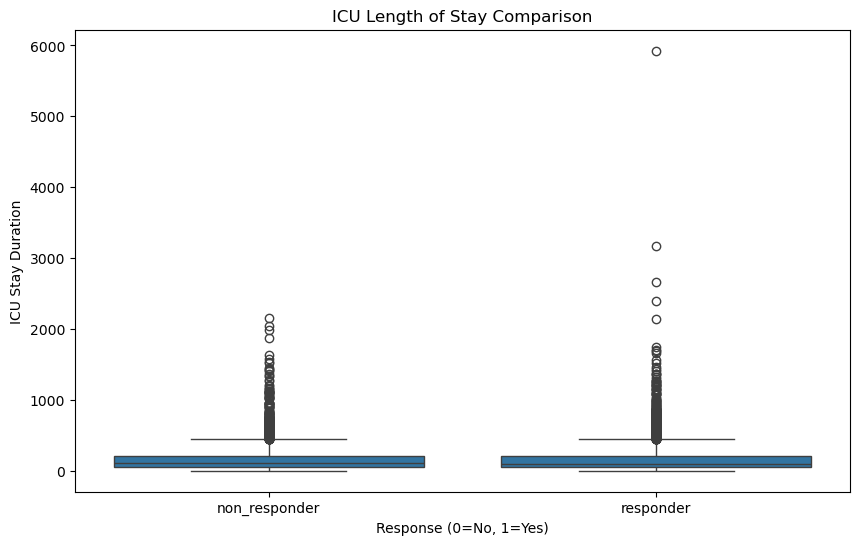

In [208]:

# 2. Categorical features analysis
categorical_features = ['gender', 'ethnicity', 'icu_outcome', 'hosp_outcome']

def categorical_analysis(df, feature):
    contingency = pd.crosstab(df[feature], df['response'])
    chi2, p_value = stats.chi2_contingency(contingency)[:2]
    
    # Calculate percentages
    percentages = pd.crosstab(df[feature], df['response'], normalize='columns') * 100
    
    return contingency, p_value, percentages

# Plot categorical features
plt.figure(figsize=(15, 10))
for idx, feature in enumerate(categorical_features, 1):
    contingency, p_value, percentages = categorical_analysis(df, feature)
    
    # _=plt.subplot(2, 3, idx)
    _=percentages.plot(kind='bar')
    _=plt.title(f'{feature} Distribution\n(p-value: {p_value:.4f})')
    _=plt.xlabel(feature)
    _=plt.ylabel('Percentage')
    _=plt.legend(['Non-Responders', 'Responders'])
_=plt.tight_layout()
plt.show()

# 3. Treatment effect analysis
_=plt.figure(figsize=(12, 6))
_=sns.boxplot(x='response', y='treatment_effect', data=df)
_=plt.title('Treatment Effect Comparison')
_=plt.xlabel('Response (0=No, 1=Yes)')
_=plt.ylabel('Treatment Effect')
_=plt.show()

# 4. Outcome analysis
outcome_comparison = pd.crosstab([df['icu_outcome'], df['hosp_outcome']], 
                               df['response'], 
                               normalize='columns') * 100
print("\nOutcome Analysis (percentages):")
print(outcome_comparison)

# # 5. Summary statistics
# print("\nSummary Statistics:")
# print(f"Total patients: {len(df)}")
# print(f"Responders: {df['response'].sum()}")
# print(f"Non-responders: {len(df) - df['response'].sum()}")
# print(f"Responders rate: {(df['response'].mean() * 100):.2f}%")

# 6. Length of stay analysis
_=plt.figure(figsize=(10, 6))
_=sns.boxplot(x='response', y='ICU_Stay', data=df)
plt.title('ICU Length of Stay Comparison')
plt.xlabel('Response (0=No, 1=Yes)')
plt.ylabel('ICU Stay Duration')
plt.show()

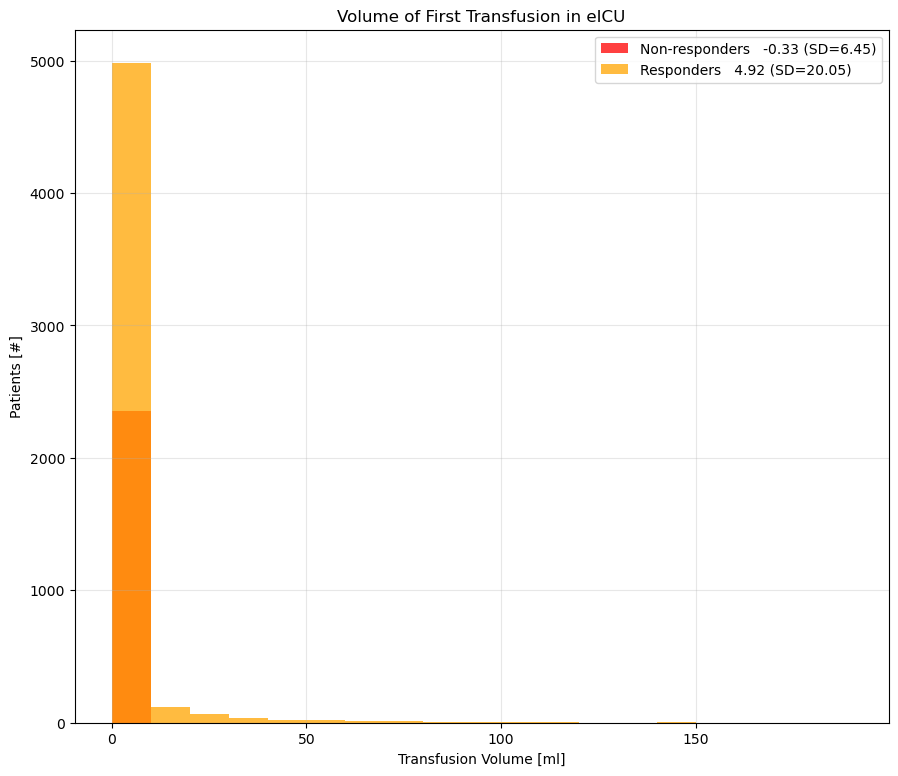

In [209]:
import numpy as np
import matplotlib.pyplot as plt

# Giovanni: this is invariant to WINDOW_SIZE and OFFSET

non_responders=df[df['response']=='non_responder']
responders=df[df['response']=='responder']

def labeled_plot(data:pd.Series,ax,label:str,f,**kwargs):
    mn=data.mean()
    sd=data.std()
    ulabel=f'{label}   {mn:.2f} (SD={sd:.2f})'
    return getattr(data.plot,f)(ax=ax,label=ulabel,**kwargs)

fig,ax=plt.subplots(figsize=(10.5,9))
_=labeled_plot(non_responders.treatment_effect_per_unit, ax,'Non-responders','hist',bins=np.arange(0,200,10),alpha=.75,color='red')
_=labeled_plot(responders.treatment_effect_per_unit,ax,'Responders','hist',bins=np.arange(0,200,10),alpha=.75, color='orange')
_=ax.set_xticks(np.arange(0,200,50))
_=ax.set_xlabel('Transfusion Volume [ml]')
_=ax.set_ylabel('Patients [#]')
_=ax.set_title('Volume of First Transfusion in eICU')
_=ax.grid(alpha=.3)
_=ax.legend()

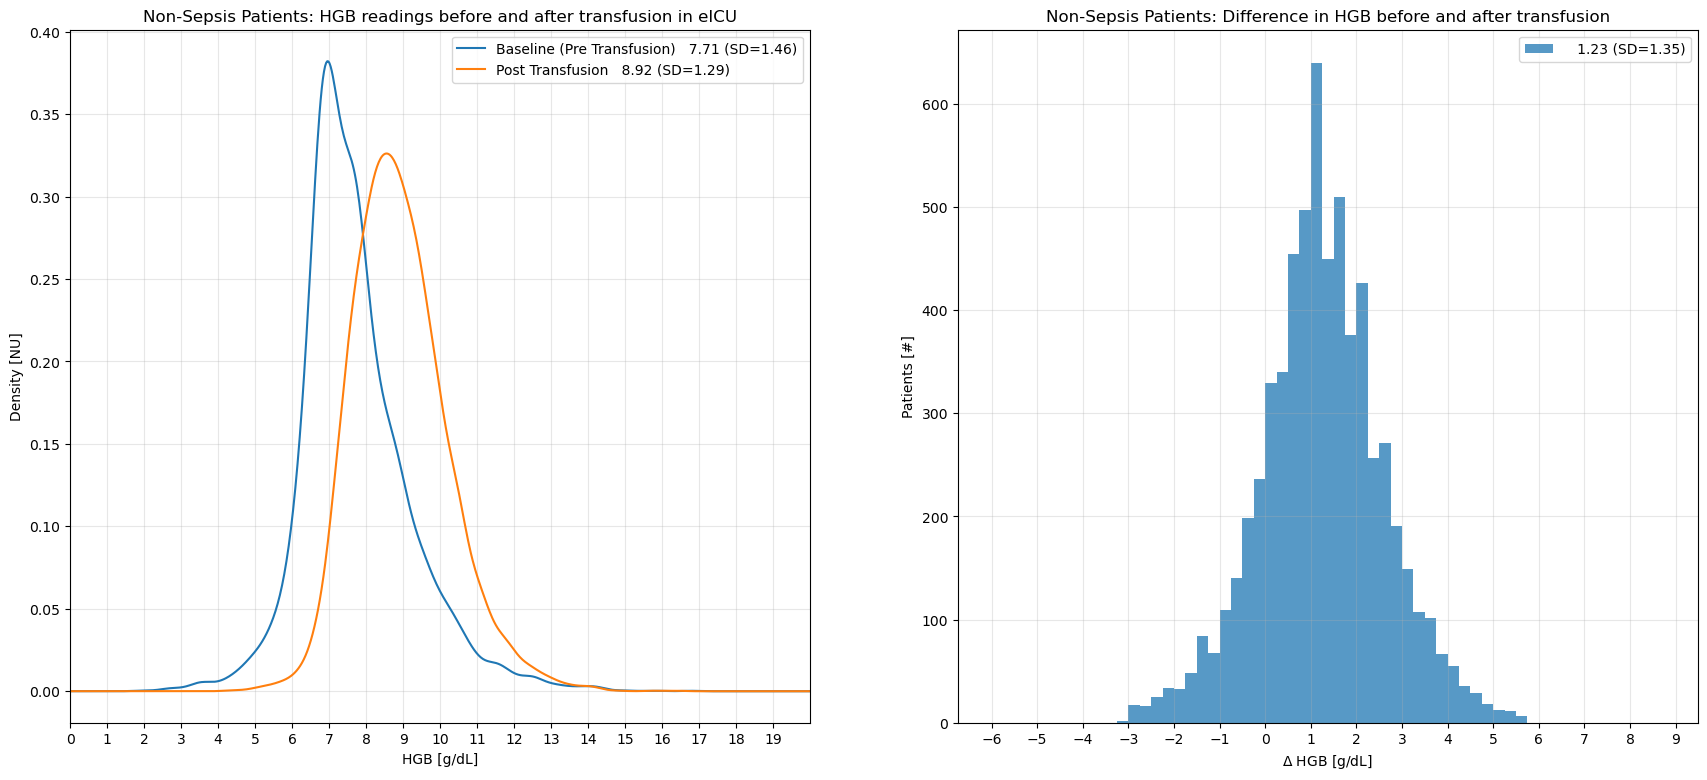

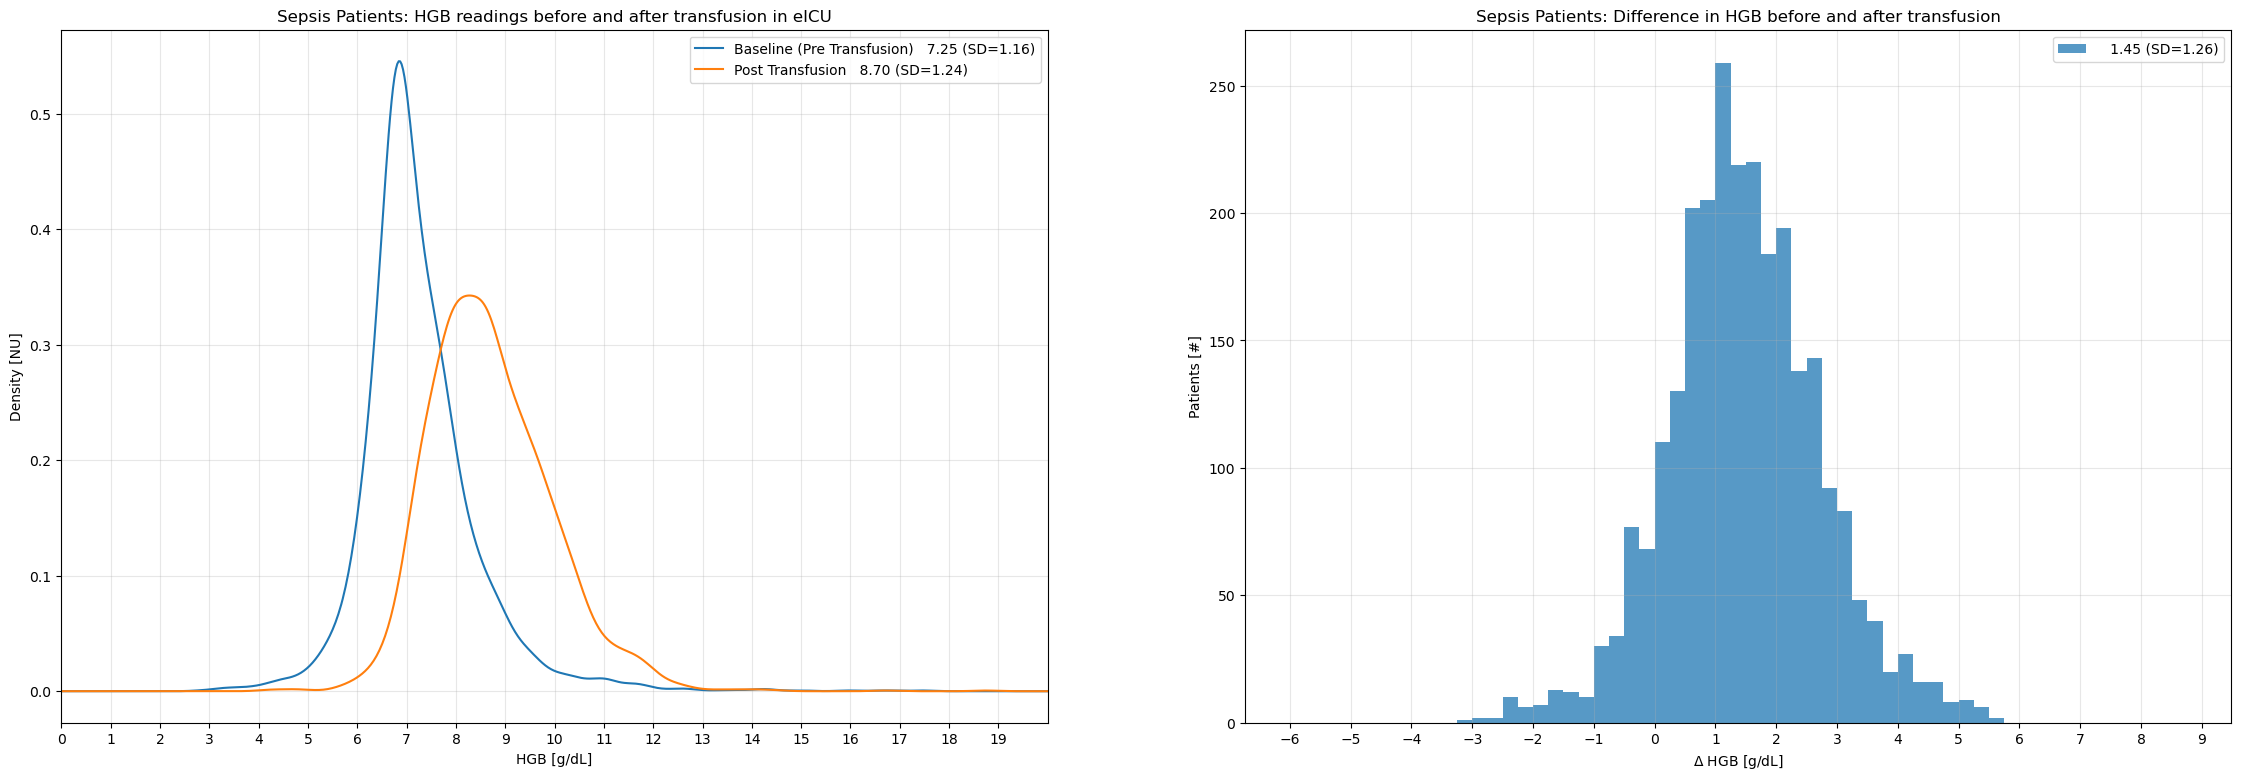

In [210]:
fig,ax=plt.subplots(1,2,figsize=(21,9))

# Non sepsis patients
_=labeled_plot(non_sepsis_df.baseline,ax=ax[0],label='Baseline (Pre Transfusion)',f='kde')
_=labeled_plot(non_sepsis_df.post_treatment,ax=ax[0],label='Post Transfusion',f='kde')

_=ax[0].legend()
_=ax[0].set_xlim([0,20])
_=ax[0].set_xticks(np.arange(0,20,1.))
_=ax[0].set_xlabel('HGB [g/dL]')
_=ax[0].set_ylabel('Density [NU]')
_=ax[0].set_title('Non-Sepsis Patients: HGB readings before and after transfusion in eICU')
_=ax[0].grid(alpha=.3)

_=labeled_plot(non_sepsis_df.treatment_effect,ax=ax[1],label='',f='hist',bins=np.arange(-6,9,.25),alpha=.75)
_=ax[1].set_xticks(np.arange(-6,10,1.))
_=ax[1].set_xlabel('$\Delta$ HGB [g/dL]')
_=ax[1].set_ylabel('Patients [#]')
_=ax[1].set_title('Non-Sepsis Patients: Difference in HGB before and after transfusion')
_=ax[1].grid(alpha=.3)
_=ax[1].legend()

# Sepsis patients
fig, ax=fig,ax=plt.subplots(1,2,figsize=(28,9))
_=labeled_plot(sepsis_df.baseline,ax=ax[0],label='Baseline (Pre Transfusion)',f='kde')
_=labeled_plot(sepsis_df.post_treatment,ax=ax[0],label='Post Transfusion',f='kde')

_=ax[0].legend()
_=ax[0].set_xlim([0,20])
_=ax[0].set_xticks(np.arange(0,20,1.))
_=ax[0].set_xlabel('HGB [g/dL]')
_=ax[0].set_ylabel('Density [NU]')
_=ax[0].set_title('Sepsis Patients: HGB readings before and after transfusion in eICU')
_=ax[0].grid(alpha=.3)

_=labeled_plot(sepsis_df.treatment_effect,ax=ax[1],label='',f='hist',bins=np.arange(-6,9,.25),alpha=.75)
_=ax[1].set_xticks(np.arange(-6,10,1.))
_=ax[1].set_xlabel('$\Delta$ HGB [g/dL]')
_=ax[1].set_ylabel('Patients [#]')
_=ax[1].set_title('Sepsis Patients: Difference in HGB before and after transfusion')
_=ax[1].grid(alpha=.3)
_=ax[1].legend()

In [211]:
# Analyze features that differentiate responders from non-responders
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import pandas as pd

# Define features and target
to_censor=['post_treatment','treatment_effect','icu_outcome','hosp_outcome', 'treatment_effect_per_unit'] 
outcome=['response']  # Binary classification target
features=['baseline','age','gender','ethnicity','initial_weight','treatment_value',
         'treatment_offset','netTotal']
categorical=['gender','ethnicity']
continuous=[val for val in features if val not in categorical]

X,y=df[features],df[outcome]

# Preprocessing pipelines
cnt_processor=Pipeline([
    ('impute',SimpleImputer()),
    ('scaling',StandardScaler())
])
cat_processor=Pipeline([
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('ohe',OneHotEncoder(drop='if_binary',sparse_output=False,min_frequency=20))
])
processor=ColumnTransformer([
    ('categorical',cat_processor,categorical),
    ('continuous',cnt_processor,continuous),
])

# Random Forest classifier with feature importance analysis
model=Pipeline([
    ('processor',processor),
    ('classifier',RandomForestClassifier(n_estimators=100, random_state=42))
])

# Stratified k-fold CV to maintain class balance
cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

# Train and evaluate model
accuracies = []
feature_importances = []

for train_idx, test_idx in cv.split(X, y):
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Train model
    model.fit(X_train, y_train.values.ravel())
    
    # Get predictions
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    
    # Get feature importance
    cat_features = model[0].named_transformers_['categorical'].get_feature_names_out(categorical)
    feature_names = np.concatenate([cat_features, continuous])
    importance = model[-1].feature_importances_
    feature_importances.append(pd.Series(importance, index=feature_names))

# Print average accuracy
print(f"Average Accuracy: {np.mean(accuracies):.3f} (+/- {np.std(accuracies):.3f})")

# Get average feature importance across folds
avg_importance = pd.concat(feature_importances, axis=1).mean(axis=1)
print("\nFeature Importances:")
print(avg_importance.sort_values(ascending=False))

Average Accuracy: 0.734 (+/- 0.008)

Feature Importances:
baseline                        0.253410
treatment_value                 0.170302
initial_weight                  0.143664
treatment_offset                0.140682
netTotal                        0.131020
age                             0.110782
gender_Male                     0.016852
ethnicity_Caucasian             0.009684
ethnicity_African American      0.007841
ethnicity_Hispanic              0.005239
ethnicity_Other/Unknown         0.004727
ethnicity_Asian                 0.002984
ethnicity_Native American       0.001977
ethnicity_                      0.000885
ethnicity_infrequent_sklearn    0.000764
dtype: float64


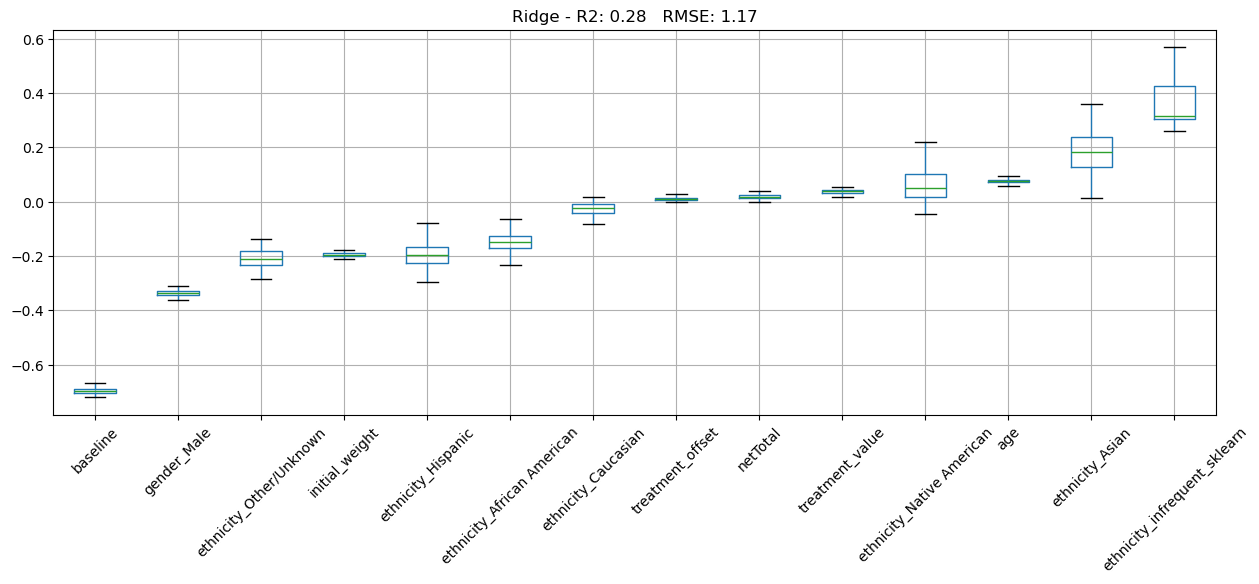

In [28]:
scores=pd.DataFrame(scores,columns=['rmse','r2'])
traces=pd.concat(trace,axis=1).T
traces=traces[traces.mean().sort_values().index]

# traces, scores=train_ridge(model, False)

fig,ax=plt.subplots(figsize=(15,5))
_=traces.boxplot(showfliers=False,rot=45,ax=ax)
_=ax.set_title(f'Ridge - R2: {scores.r2.mean():.2f}   RMSE: {scores.rmse.mean():.2f}')
plt.savefig('sepsis_features.png', dpi=300)

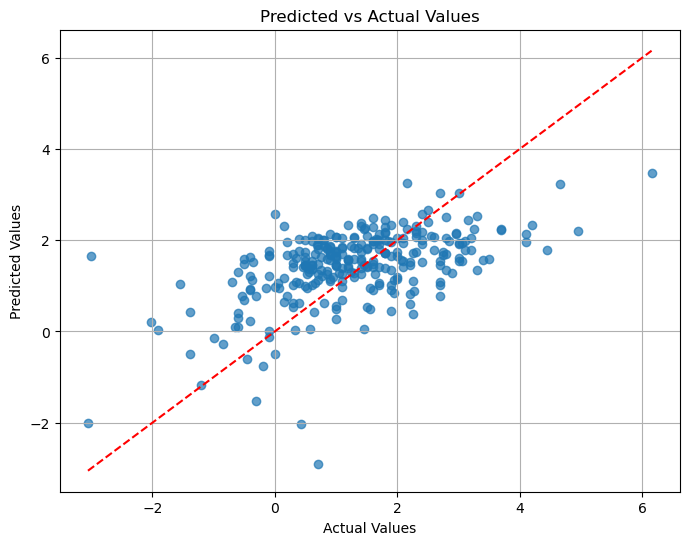

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(y.iloc[test], y_pred, alpha=0.7, label='Actual')
# plt.scatter(y.iloc[test], alpha=0.7, label='Predicted', color='red')
plt.plot([min(y.iloc[test]['treatment_effect']), max(y.iloc[test]['treatment_effect'])], [min(y.iloc[test]['treatment_effect']), max(y.iloc[test]['treatment_effect'])], color='red', linestyle='--')  # Line of perfect prediction
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values')
plt.grid(True)
plt.savefig('PCA_Ridge_plot.png', dpi=300)
plt.show()